<a href="https://colab.research.google.com/github/a2w3r4/Exo-planet-Search-in-Space/blob/main/Predicting_Stars_Quasars_and_Galaxies.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# About the Problem & Our Dataset

In [ ]:
import os

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow import keras

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from sklearn.metrics import accuracy_score

from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

import warnings
warnings.filterwarnings("ignore")

%matplotlib inline

In [ ]:
!pip install opendatasets

In [ ]:
import opendatasets as od
od.download("https://www.kaggle.com/datasets/lucidlenn/sloan-digital-sky-survey")

Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username: Rishu Raj
Your Kaggle Key: ··········
Dataset URL: https://www.kaggle.com/datasets/lucidlenn/sloan-digital-sky-survey


100%|██████████| 446k/446k [00:00<00:00, 620MB/s]

In [ ]:
find_star = pd.read_csv("/content/sloan-digital-sky-survey/Skyserver_SQL2_27_2018 6_51_39 PM.csv")

In [ ]:
find_star

,ra,dec,u,g,r,i,z,run,rerun,camcol,field,class,redshift,plate,mjd,fiberid
0,183.531326,0.089693,19.47406,17.04240,15.94699,15.50342,15.22531,752,301,4,267,STAR,-0.000009,3306,54922,491
1,183.598370,0.135285,18.66280,17.21449,16.67637,16.48922,16.39150,752,301,4,267,STAR,-0.000055,323,51615,541
2,183.680207,0.126185,19.38298,18.19169,17.47428,17.08732,16.80125,752,301,4,268,GALAXY,0.123111,287,52023,513
3,183.870529,0.049911,17.76536,16.60272,16.16116,15.98233,15.90438,752,301,4,269,STAR,-0.000111,3306,54922,510
4,183.883288,0.102557,17.55025,16.26342,16.43869,16.55492,16.61326,752,301,4,269,STAR,0.000590,3306,54922,512
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,131.316413,51.539547,18.81777,17.47053,16.91508,16.68305,16.50570,1345,301,3,161,GALAXY,0.027583,447,51877,246
9996,131.306083,51.671341,18.27255,17.43849,17.07692,16.71661,16.69897,1345,301,3,162,GALAXY,0.117772,447,51877,228
9997,131.552562,51.666986,18.75818,17.77784,17.51872,17.43302,17.42048,1345,301,3,162,STAR,-0.000402,7303,57013,622
9998,131.477151,51.753068,18.88287,17.91068,17.53152,17.36284,17.13988,1345,301,3,163,GALAXY,0.014019,447,51877,229


In [ ]:
find_star.head()

,objid,ra,dec,u,g,r,i,z,run,rerun,camcol,field,specobjid,class,redshift,plate,mjd,fiberid
0,1.237650e+18,183.531326,0.089693,19.47406,17.04240,15.94699,15.50342,15.22531,752,301,4,267,3.722360e+18,STAR,-0.000009,3306,54922,491
1,1.237650e+18,183.598370,0.135285,18.66280,17.21449,16.67637,16.48922,16.39150,752,301,4,267,3.638140e+17,STAR,-0.000055,323,51615,541
2,1.237650e+18,183.680207,0.126185,19.38298,18.19169,17.47428,17.08732,16.80125,752,301,4,268,3.232740e+17,GALAXY,0.123111,287,52023,513
3,1.237650e+18,183.870529,0.049911,17.76536,16.60272,16.16116,15.98233,15.90438,752,301,4,269,3.722370e+18,STAR,-0.000111,3306,54922,510
4,1.237650e+18,183.883288,0.102557,17.55025,16.26342,16.43869,16.55492,16.61326,752,301,4,269,3.722370e+18,STAR,0.000590,3306,54922,512


In [ ]:
find_star.shape

(10000, 18)

In [ ]:
find_star.drop(['objid','specobjid'], axis=1, inplace=True)

In [ ]:
find_star.head(10)

,ra,dec,u,g,r,i,z,run,rerun,camcol,field,class,redshift,plate,mjd,fiberid
0,183.531326,0.089693,19.47406,17.04240,15.94699,15.50342,15.22531,752,301,4,267,STAR,-0.000009,3306,54922,491
1,183.598370,0.135285,18.66280,17.21449,16.67637,16.48922,16.39150,752,301,4,267,STAR,-0.000055,323,51615,541
2,183.680207,0.126185,19.38298,18.19169,17.47428,17.08732,16.80125,752,301,4,268,GALAXY,0.123111,287,52023,513
3,183.870529,0.049911,17.76536,16.60272,16.16116,15.98233,15.90438,752,301,4,269,STAR,-0.000111,3306,54922,510
4,183.883288,0.102557,17.55025,16.26342,16.43869,16.55492,16.61326,752,301,4,269,STAR,0.000590,3306,54922,512
5,183.847174,0.173694,19.43133,18.46779,18.16451,18.01475,18.04155,752,301,4,269,STAR,0.000315,324,51666,594
6,183.864379,0.019201,19.38322,17.88995,17.10537,16.66393,16.36955,752,301,4,269,GALAXY,0.100242,287,52023,559
7,183.900081,0.187473,18.97993,17.84496,17.38022,17.20673,17.07071,752,301,4,269,STAR,0.000315,3306,54922,515
8,183.924588,0.097246,17.90616,16.97172,16.67541,16.53776,16.47596,752,301,4,270,STAR,0.000089,323,51615,595
9,183.973498,0.081626,18.67249,17.71375,17.49362,17.28284,17.22644,752,301,4,270,GALAXY,0.040508,288,52000,400


In [ ]:
find_star.shape

(10000, 16)

In [ ]:
find_star.describe()

,ra,dec,u,g,r,i,z,run,rerun,camcol,field,redshift,plate,mjd,fiberid
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.0,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,175.529987,14.836148,18.619355,17.371931,16.840963,16.583579,16.422833,981.034800,301.0,3.648700,302.380100,0.143726,1460.986400,52943.533300,353.069400
std,47.783439,25.212207,0.828656,0.945457,1.067764,1.141805,1.203188,273.305024,0.0,1.666183,162.577763,0.388774,1788.778371,1511.150651,206.298149
min,8.235100,-5.382632,12.988970,12.799550,12.431600,11.947210,11.610410,308.000000,301.0,1.000000,11.000000,-0.004136,266.000000,51578.000000,1.000000
25%,157.370946,-0.539035,18.178035,16.815100,16.173333,15.853705,15.618285,752.000000,301.0,2.000000,184.000000,0.000081,301.000000,51900.000000,186.750000
50%,180.394514,0.404166,18.853095,17.495135,16.858770,16.554985,16.389945,756.000000,301.0,4.000000,299.000000,0.042591,441.000000,51997.000000,351.000000
75%,201.547279,35.649397,19.259232,18.010145,17.512675,17.258550,17.141447,1331.000000,301.0,5.000000,414.000000,0.092579,2559.000000,54468.000000,510.000000
max,260.884382,68.542265,19.599900,19.918970,24.802040,28.179630,22.833060,1412.000000,301.0,6.000000,768.000000,5.353854,8410.000000,57481.000000,1000.000000


In [ ]:
find_star.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   ra        10000 non-null  float64
 1   dec       10000 non-null  float64
 2   u         10000 non-null  float64
 3   g         10000 non-null  float64
 4   r         10000 non-null  float64
 5   i         10000 non-null  float64
 6   z         10000 non-null  float64
 7   run       10000 non-null  int64  
 8   rerun     10000 non-null  int64  
 9   camcol    10000 non-null  int64  
 10  field     10000 non-null  int64  
 11  class     10000 non-null  object 
 12  redshift  10000 non-null  float64
 13  plate     10000 non-null  int64  
 14  mjd       10000 non-null  int64  
 15  fiberid   10000 non-null  int64  
dtypes: float64(8), int64(7), object(1)
memory usage: 1.2+ MB


## The Target from data is Data Classification to Star, Galaxy or Quasar, so the class column has 3 Categories and in the case we need to convert them into numeric data

Sklearn provides a very efficient tool for encoding the levels of categorical features into numeric values. LabelEncoder().fit encodes labels with a value between 0 and n_classes-1 where n is the number of district labels. If a label repeats it assigns the value to as assigned earlier.

In [ ]:
# All others are in numeric but Class is not. So, we need to make it in numeric

In [ ]:
le = LabelEncoder().fit(find_star['class'])
find_star['class'] = le.transform(find_star['class'])

# The Final Dataset

In [ ]:
find_star.head(10)

,ra,dec,u,g,r,i,z,run,rerun,camcol,field,class,redshift,plate,mjd,fiberid
0,183.531326,0.089693,19.47406,17.04240,15.94699,15.50342,15.22531,752,301,4,267,2,-0.000009,3306,54922,491
1,183.598370,0.135285,18.66280,17.21449,16.67637,16.48922,16.39150,752,301,4,267,2,-0.000055,323,51615,541
2,183.680207,0.126185,19.38298,18.19169,17.47428,17.08732,16.80125,752,301,4,268,0,0.123111,287,52023,513
3,183.870529,0.049911,17.76536,16.60272,16.16116,15.98233,15.90438,752,301,4,269,2,-0.000111,3306,54922,510
4,183.883288,0.102557,17.55025,16.26342,16.43869,16.55492,16.61326,752,301,4,269,2,0.000590,3306,54922,512
5,183.847174,0.173694,19.43133,18.46779,18.16451,18.01475,18.04155,752,301,4,269,2,0.000315,324,51666,594
6,183.864379,0.019201,19.38322,17.88995,17.10537,16.66393,16.36955,752,301,4,269,0,0.100242,287,52023,559
7,183.900081,0.187473,18.97993,17.84496,17.38022,17.20673,17.07071,752,301,4,269,2,0.000315,3306,54922,515
8,183.924588,0.097246,17.90616,16.97172,16.67541,16.53776,16.47596,752,301,4,270,2,0.000089,323,51615,595
9,183.973498,0.081626,18.67249,17.71375,17.49362,17.28284,17.22644,752,301,4,270,0,0.040508,288,52000,400


In [ ]:
find_star.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   ra        10000 non-null  float64
 1   dec       10000 non-null  float64
 2   u         10000 non-null  float64
 3   g         10000 non-null  float64
 4   r         10000 non-null  float64
 5   i         10000 non-null  float64
 6   z         10000 non-null  float64
 7   run       10000 non-null  int64  
 8   rerun     10000 non-null  int64  
 9   camcol    10000 non-null  int64  
 10  field     10000 non-null  int64  
 11  class     10000 non-null  int64  
 12  redshift  10000 non-null  float64
 13  plate     10000 non-null  int64  
 14  mjd       10000 non-null  int64  
 15  fiberid   10000 non-null  int64  
dtypes: float64(8), int64(8)
memory usage: 1.2 MB


We can understand that the dataset is complete with no null values. And since the dataset has only nmerical values now, there's no need of further encoding and type conversions

Perform train and split

In [ ]:
x = find_star.drop('class', axis=1)
y = find_star['class']

# Data Scaling

Scaling means converting floating-point feature values from their natural range ( for example, 100 to 900) into a standard range -- usually 0 and 1 (or sometimes -1 to +1). StandardScaler follows Standard Normal Distribution (SND). Therefore, it makes mean = 0 and scales the data to unit variance.

In [ ]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler(copy=True, with_mean=True, with_std = True)
x = scaler.fit_transform(x)

In [ ]:
x[:20]

array([[ 0.16745842, -0.58492272,  1.03148637, -0.34855938, -0.83728027,
        -0.94605772, -0.99534154, -0.83806089,  0.        ,  0.21085172,
        -0.21763043, -0.36973112,  1.03148936,  1.30931064,  0.66863177],
       [ 0.16886159, -0.58311429,  0.05243046, -0.16653251, -0.15415531,
        -0.08264457, -0.02604308, -0.83806089,  0.        ,  0.21085172,
        -0.21763043, -0.36984929, -0.63621258, -0.87919741,  0.91101156],
       [ 0.17057433, -0.58347525,  0.92156796,  0.86709322,  0.59315368,
         0.44120145,  0.31452753, -0.83806089,  0.        ,  0.21085172,
        -0.21147922, -0.05302706, -0.65633905, -0.60919097,  0.77527888],
       [ 0.17455754, -0.58650069, -1.03063038, -0.81362749, -0.63669227,
        -0.52660429, -0.43092107, -0.83806089,  0.        ,  0.21085172,
        -0.20532801, -0.36999261,  1.03148936,  1.30931064,  0.76073609],
       [ 0.17482457, -0.58441247, -1.29023238, -1.17251944, -0.37676237,
        -0.02510121,  0.15827647, -0.83806089, 

In [ ]:
# Perform the 30% test and 70% train split here
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=128)

# Density Distribution Plots

<Axes: xlabel='class', ylabel='count'>

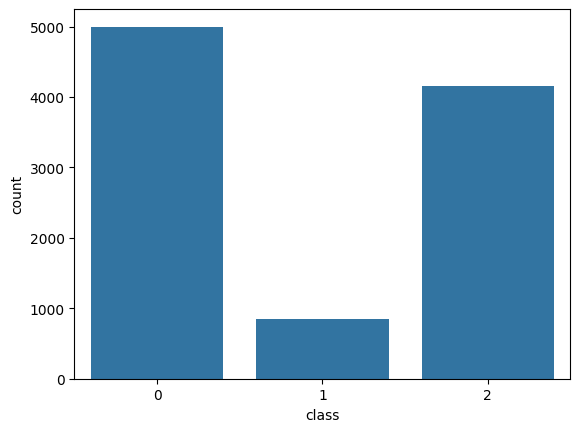

In [ ]:
# Checking the number of labels for each class of the datset where 0 = Galaxy, 1 = Quasar, 2 = Star
sns.countplot(x=find_star['class'])

## Some Information about the filters used while gathering the data

"U" stands for ultraviolet. "G" stands for green. "R" stands for red. "I" stands for infrared.

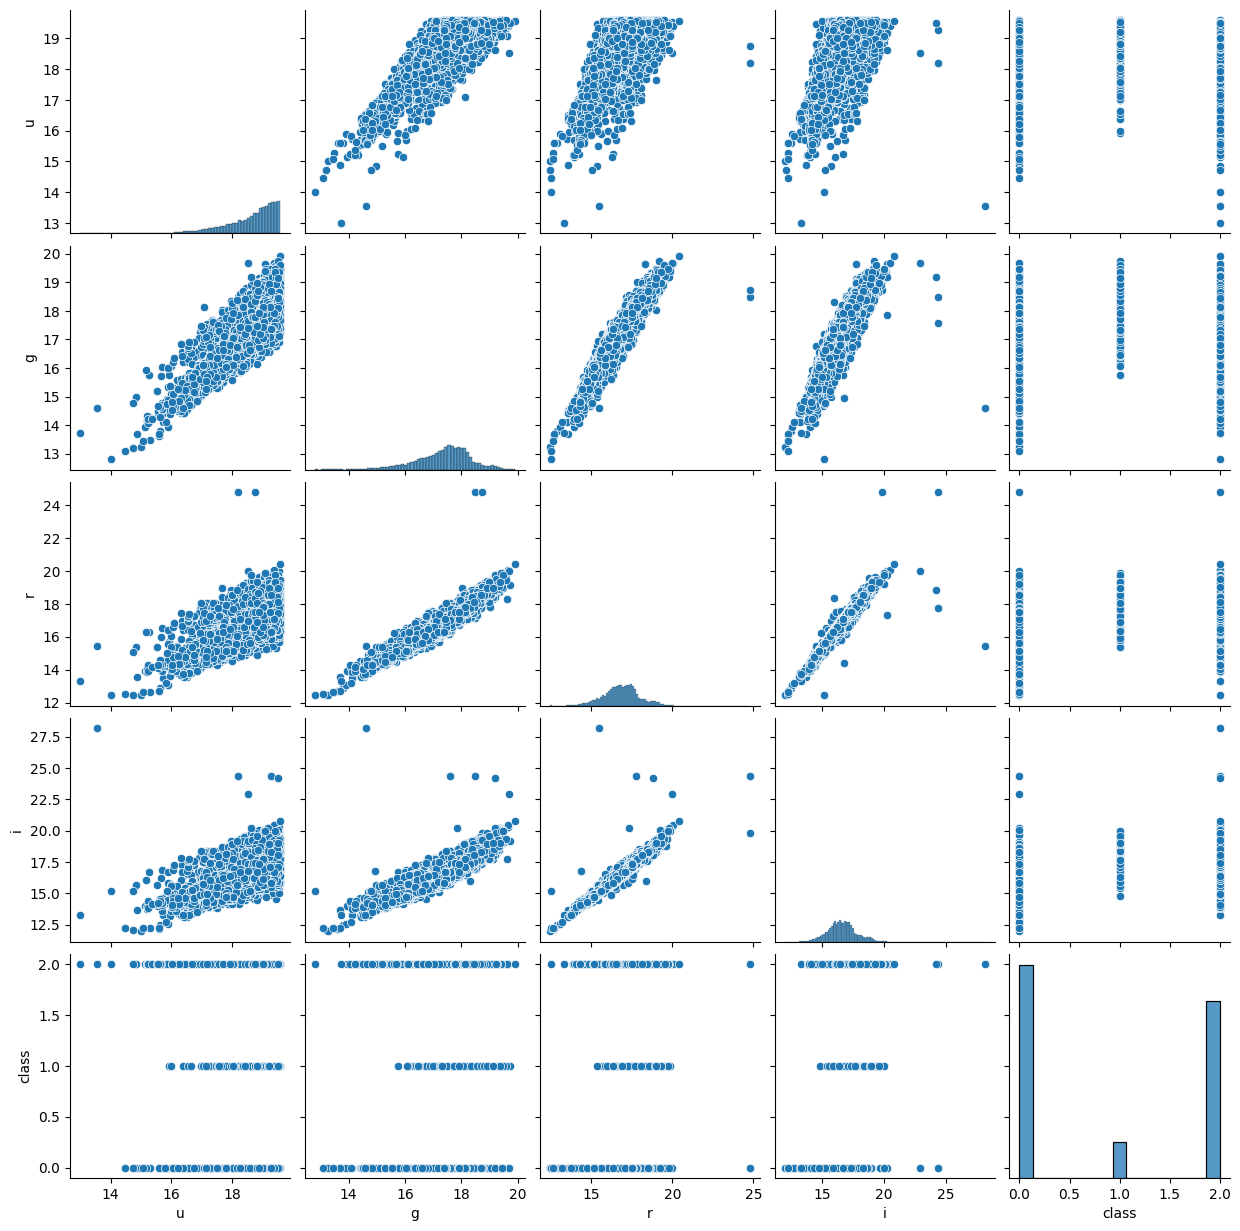

In [ ]:
# Using pairplots to establish and understand interdependency of train features
sns.pairplot(find_star[['u', 'g', 'r', 'i', 'class']])

# Machine Learning Models (Classification Models)

# Decision Tree Classifier -

The decision of making strategic splits heavily affects a tree's accuracy. The decision criteria are different for classficaation and regression trees.

Decision trees uses multiple algorithms to decide to split a node in two or more sub-nodes. The creation of sub-nodes increases the homogeneity of resultant sub-nodes. In other words, we can sasy that the purity of the node increases with respect to the target variable. The decision tree splits the nodes on all available variables and then selects the splits which results in most homogeneous sub-nodes.

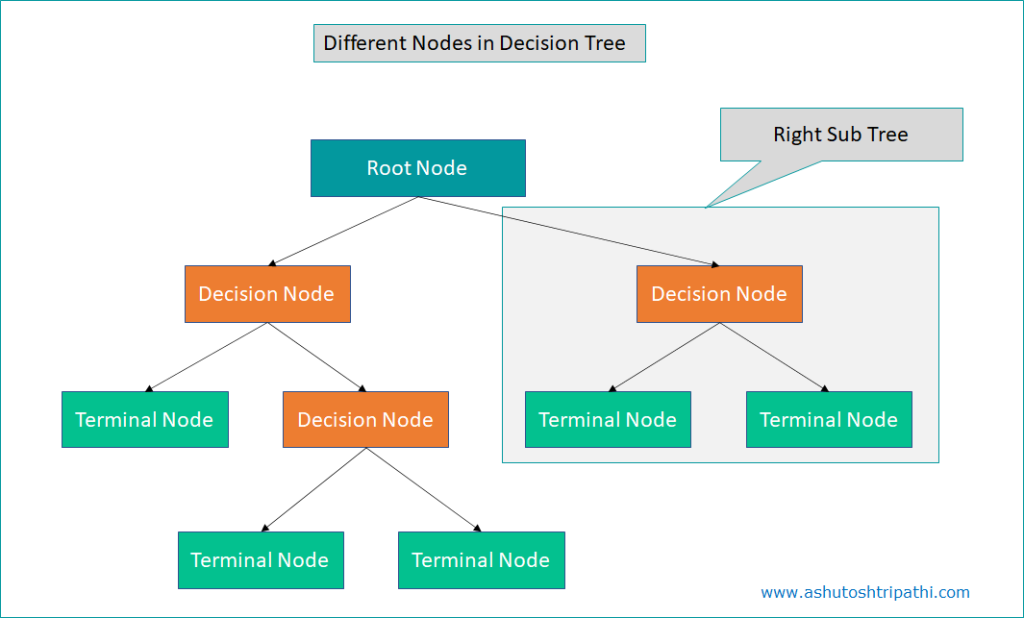

The algorithm selection is also based on the type of target variables. Let us look at some algorithms used in Decision Trees:

1. ID3 --> (extension of D3)
2. C4.5 --> (successor of ID3)
3. CART --> (Classification and Regression Tree)
4. CHAID --> (Chi-square automatic interaction detection Performs multi-level splits when computing classification trees)
5. MARS --> (multivariate adopative regression splines)

Example of ID3:
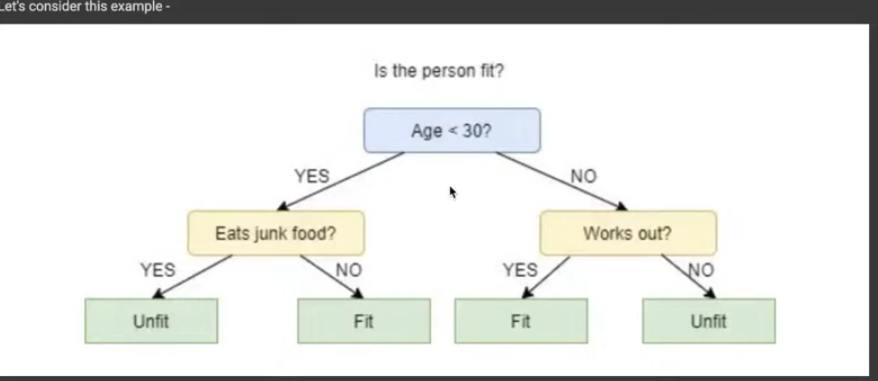

The initial node is called th **root** node (colored in blue), The final nodes are called the **leaf** nodes(colored in green) and the rest of the nodes are called Intermediate or Internal nodes. The root and intermediate noes represent the decision while leaf nodes represent the outcomes.

ID3 stands for Iterative Dichotomiser 3 and is named such beacuse the algorithm iteratively (repeatively) dichotomized(divides) features into two or more groups at each step. Invented by Ross Quinlan, ID3 uses a top-down greedy approach to build a decision tree. In simple words, the top-down approach means that we start building the treefrom  the top and greedy approach means that at each iteration we select the best feature at the present moment to create a node. **Most generally ID3 is only used for classification problems with nominal features only.**.

ID3 uses Information gain or just Gain to find the best feature. Information Gain calculates the reduction in the entropy and measures how well a given feature seperates or classfies the target classes. The feature with the highest Information Gain is selected as the best one.

In simple words, Entropy is the measure of disorder and the Entropy of a datset is the measure of disorder in the target feature of the dataset.

In the case of Binary Classification ( where the target clumn has only two types of classes) entropy is 0 if all values in the target column are homogeneous (similar) amd will be 1 if the target column has equal number values for bith the classes.

ID3 Steps -

1. Calculate the Information Gain of each feature.
2. Considering that all rows don't belong to the same class, split the dataset S into subset using the feature for which the Information Gain is maximum.
3. Make a decision tree node using the feature with the maximum information gain.
4. If all rows belong to the same class, make the current node as a leaf node with the class as its label.
5. Repeat for the remaining features until we runout of all features, or the decision tree has all leaf nodes.

We denote our dataset as S, entropy is calculate as -

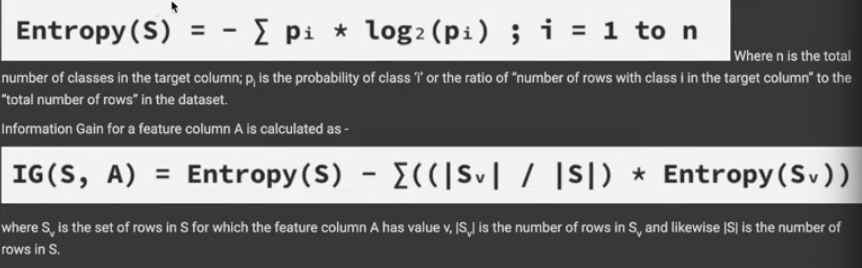

In [ ]:
# Decision Tree Classifier

In [ ]:
dtClassifer = DecisionTreeClassifier(max_leaf_nodes=15, max_depth=3)

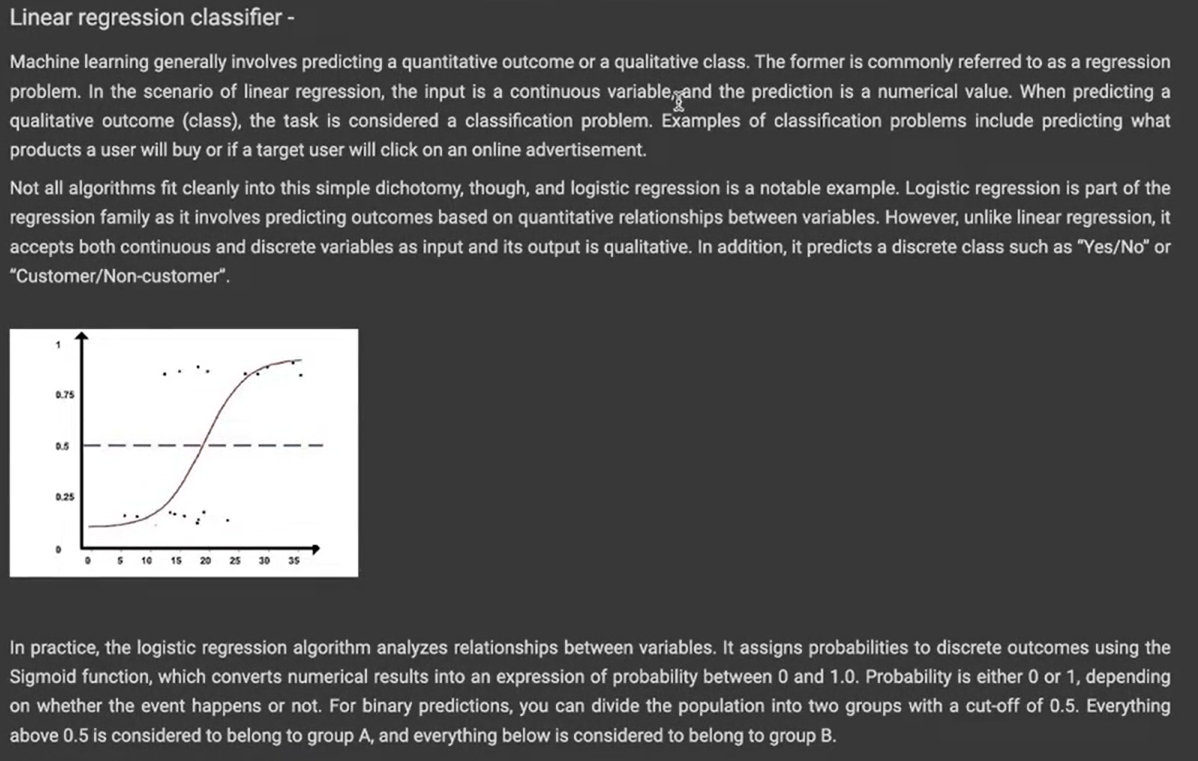

In [ ]:
# Linear Classifier -- Logistic Regression

In [ ]:
LRClassifer = LogisticRegression()

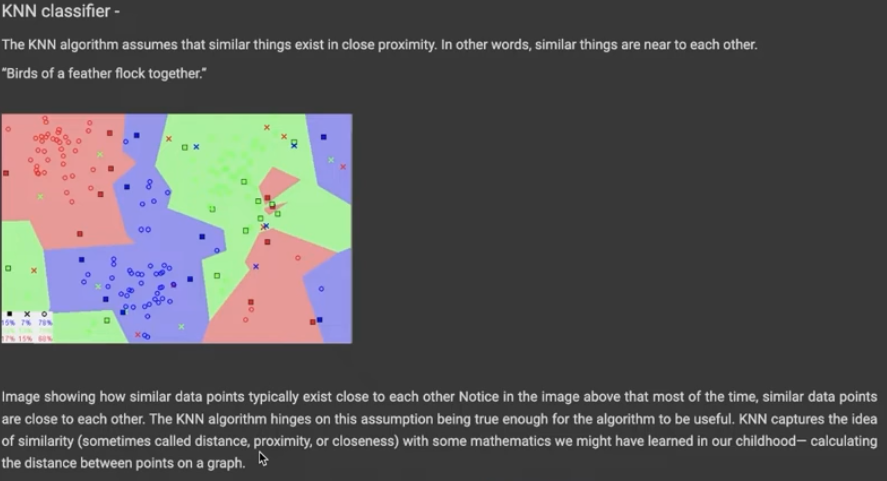

In [ ]:
# Nearest Neighbor Classifier

In [ ]:
NeNeClassifer = KNeighborsClassifier(n_neighbors=3)

In [ ]:
# Fitting the models to the dataset
dtClassifer.fit(x_train, y_train)

LRClassifer.fit(x_train, y_train)

NeNeClassifer.fit(x_train, y_train)

KNeighborsClassifier(n_neighbors=3)

In [ ]:
# Getting the prediciton set of the models
y_preds = dtClassifer.predict(x_test)
y_predsLR = LRClassifer.predict(x_test)
y_predsNeNe = NeNeClassifer.predict(x_test)

In [ ]:
# Displaying the last 10 predicitions on the test split as output by all the models

In [ ]:
print(y_preds[:10], '\n', y_test[:10])

print("\n*********************************************************")
print(y_predsLR[:10], '\n', y_test[:10])

print("\n*********************************************************")
print(y_predsNeNe[:10], '\n', y_test[:10])



[2 0 2 2 0 0 2 1 0 0] 
 7054    2
4692    0
907     2
4498    2
9957    0
3341    0
7152    2
1152    1
7105    0
2066    0
Name: class, dtype: int64

*********************************************************
[2 0 2 2 0 0 2 1 0 0] 
 7054    2
4692    0
907     2
4498    2
9957    0
3341    0
7152    2
1152    1
7105    0
2066    0
Name: class, dtype: int64

*********************************************************
[2 0 2 2 0 0 2 1 0 0] 
 7054    2
4692    0
907     2
4498    2
9957    0
3341    0
7152    2
1152    1
7105    0
2066    0
Name: class, dtype: int64


In [ ]:
from sklearn.metrics import classification_report
target_names = ['0', '1', '2']

print('\033[lm Decision Tree -\n \033[0m',classification_report(y_preds, y_test, target_names=target_names) + '\n')
print('\033[lm Linear Regression -\n \033[0m',classification_report(y_predsLR, y_test, target_names=target_names) + '\n')
print('\033[lm KNN Classifier -\n \033[0m',classification_report(y_predsNeNe, y_test, target_names=target_names) + '\n')


m Decision Tree -
                precision    recall  f1-score   support

           0       0.99      0.99      0.99      1504
           1       0.94      0.98      0.96       255
           2       1.00      1.00      1.00      1241

    accuracy                           0.99      3000
   macro avg       0.98      0.99      0.98      3000
weighted avg       0.99      0.99      0.99      3000


m Linear Regression -
                precision    recall  f1-score   support

           0       0.97      0.99      0.98      1469
           1       0.94      0.97      0.96       258
           2       0.99      0.96      0.98      1273

    accuracy                           0.98      3000
   macro avg       0.97      0.97      0.97      3000
weighted avg       0.98      0.98      0.98      3000


m KNN Classifier -
                precision    recall  f1-score   support

           0       0.94      0.89      0.91      1575
           1       0.88      0.97      0.92       240
        

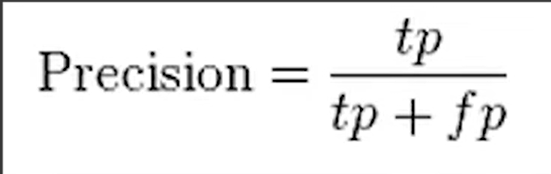

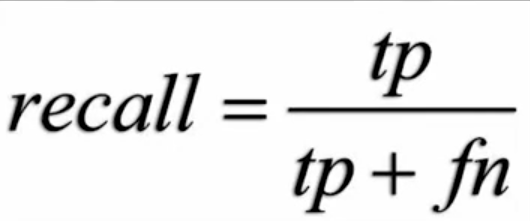

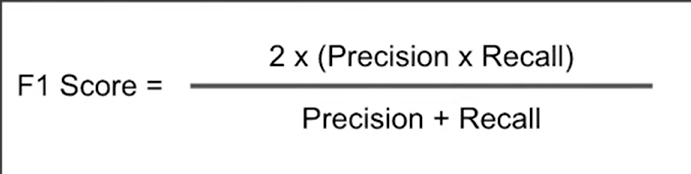